In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartphone_cleaned_v3.csv")
df

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,snapdragon,8.0,3.20,...,6.70,120,1440 x 3216,3,1.0,android,50.0,16.0,0,NaN
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,snapdragon,8.0,2.20,...,6.59,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,exynos,8.0,2.40,...,6.60,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,snapdragon,8.0,2.20,...,6.55,120,1080 x 2400,3,1.0,android,50.0,16.0,1,1024.0
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,dimensity,8.0,2.60,...,6.70,120,1080 x 2412,3,1.0,android,108.0,16.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,motorola,Motorola Moto Edge S30 Pro,34990,83.0,True,False,False,snapdragon,8.0,3.00,...,6.67,120,1080 x 2460,3,1.0,android,64.0,16.0,0,NaN
976,honor,Honor X8 5G,14990,75.0,True,False,False,snapdragon,8.0,2.20,...,6.50,60,720 x 1600,3,1.0,android,48.0,8.0,1,1024.0
977,poco,POCO X4 GT 5G (8GB RAM + 256GB),28990,85.0,True,True,True,dimensity,8.0,2.85,...,6.60,144,1080 x 2460,3,1.0,android,64.0,16.0,0,NaN
978,motorola,Motorola Moto G91 5G,19990,80.0,True,True,False,snapdragon,8.0,2.20,...,6.80,60,1080 x 2400,3,1.0,android,108.0,32.0,1,1024.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   rating                     879 non-null    float64
 4   has_5g                     980 non-null    bool   
 5   has_nfc                    980 non-null    bool   
 6   has_ir_blaster             980 non-null    bool   
 7   processor_brand            960 non-null    object 
 8   num_cores                  974 non-null    float64
 9   processor_speed            938 non-null    float64
 10  battery_capacity           969 non-null    float64
 11  fast_charging_available    980 non-null    int64  
 12  fast_charging              769 non-null    float64
 13  ram_capacity               980 non-null    float64

In [4]:
df.shape

(980, 25)

The analysis is for to build a predict price of the phone when we give ram, rom ... etc. So my whole EDA analysis is in the around price column. So we understand the relationship of other column with price.

In [5]:
df["brand_name"] = df["brand_name"].astype("category")

In [6]:
df["os"] = df["os"].astype("category")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   brand_name                 980 non-null    category
 1   model                      980 non-null    object  
 2   price                      980 non-null    int64   
 3   rating                     879 non-null    float64 
 4   has_5g                     980 non-null    bool    
 5   has_nfc                    980 non-null    bool    
 6   has_ir_blaster             980 non-null    bool    
 7   processor_brand            960 non-null    object  
 8   num_cores                  974 non-null    float64 
 9   processor_speed            938 non-null    float64 
 10  battery_capacity           969 non-null    float64 
 11  fast_charging_available    980 non-null    int64   
 12  fast_charging              769 non-null    float64 
 13  ram_capacity               980 non-

### Starting our EDA

#### Univariate Analysis
- brand_name column

<Axes: ylabel='count'>

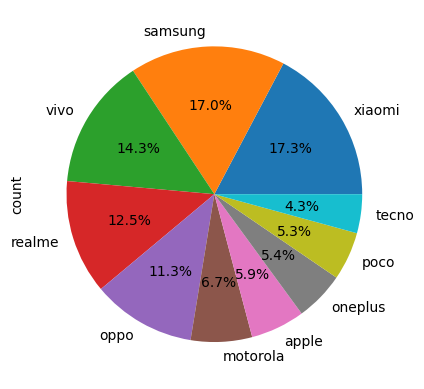

In [8]:
# Top 10 most numbered phone model are available in market, plot pie chart
df["brand_name"].value_counts().head(10).plot(kind="pie", autopct="%0.1f%%")

- Price column

In [9]:
df["price"].describe()

count       980.000000
mean      32520.504082
std       39531.812669
min        3499.000000
25%       12999.000000
50%       19994.500000
75%       35491.500000
max      650000.000000
Name: price, dtype: float64

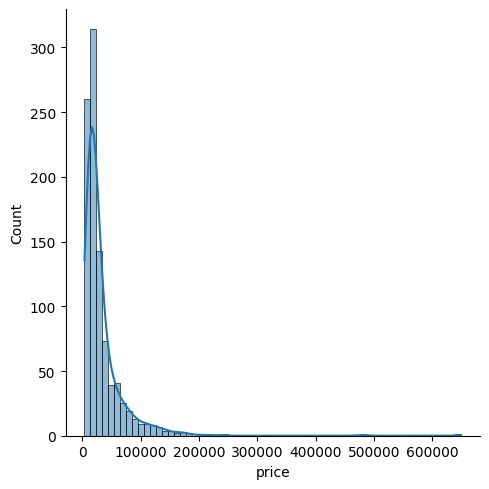

In [10]:
sns.displot(data=df,x="price", kind='hist', kde=True)

In [11]:
df["price"].skew()

np.float64(6.591790999665567)

<Axes: xlabel='price'>

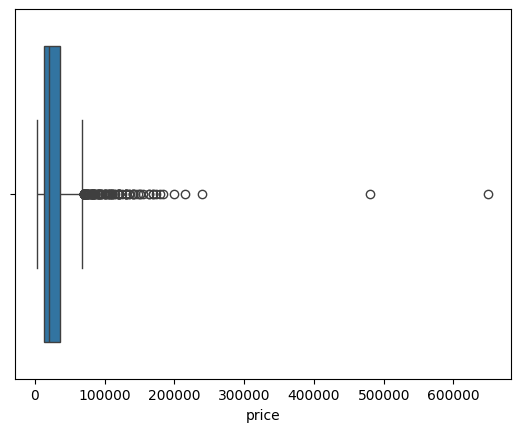

In [12]:
sns.boxplot(data=df, x="price")

In [13]:
df[df["price"] > 200000]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
427,vertu,Vertu Signature Touch,650000,62.0,False,True,False,snapdragon,8.0,1.50,...,4.70,60,1080 x 1920,1,1.0,android,13.0,2.1,0,NaN
478,huawei,Huawei Mate 50 RS Porsche Design,239999,81.0,False,True,True,snapdragon,8.0,3.20,...,6.74,120,1212 x 2616,3,1.0,other,50.0,13.0,1,256.0
887,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,480000,88.0,False,True,False,snapdragon,8.0,2.80,...,6.39,60,1080 x 2340,3,1.0,android,48.0,20.0,0,NaN
951,huawei,Huawei Mate 30 RS Porsche Design,214990,NaN,True,True,True,kirin,8.0,2.86,...,6.53,60,1176 x 2400,4,2.0,android,40.0,32.0,1,256.0


These phones are expensive because of gold / diamond / luxury materials

Their specifications (RAM, battery, 5G, processor, etc.) do NOT justify the price

These luxury features are not present in other columns

You want a specification-based price prediction model

 These rows will confuse the model. They are TRUE outliers for YOUR problem

In [14]:
df = df[df["price"] <= 200000].reset_index(drop=True)

**Conclusion** -:

I do analysis like hist plot with kde true and also do boxplot on the price column and see there are many outlires are there where I removed them in my dataset to better analysis bcz these outliers datas have no relation with any column and their specification also not justify their price.


In [15]:
df["rating"].describe()

count    876.000000
mean      78.262557
std        7.387218
min       60.000000
25%       74.000000
50%       80.000000
75%       84.000000
max       89.000000
Name: rating, dtype: float64

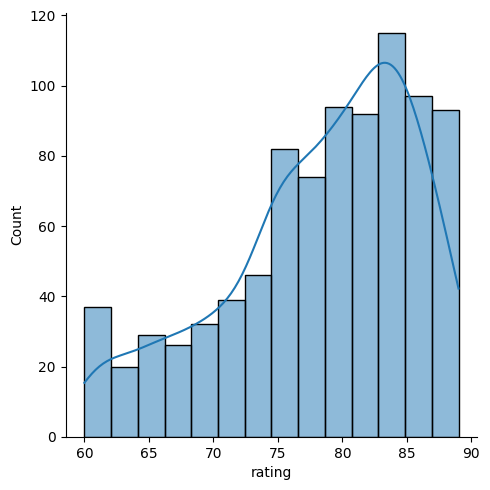

In [16]:
sns.displot(data=df,x="rating", kind='hist', kde=True)

In [17]:
df["rating"].skew()

np.float64(-0.6980929290123327)

<Axes: xlabel='rating'>

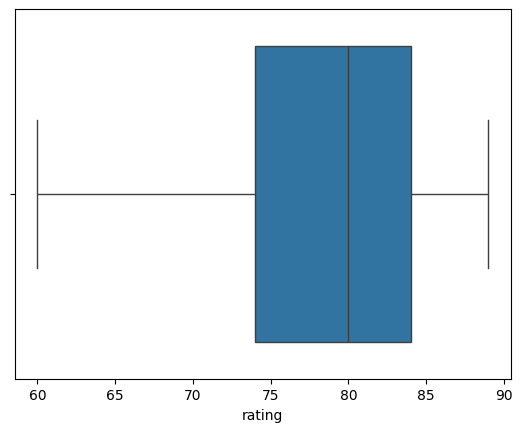

In [18]:
sns.boxplot(data=df, x="rating")

In [19]:
df["rating"].isnull().sum()/980

np.float64(0.10204081632653061)

In the rating column the distribution is near to normal and there are not any outliers. Or There are most number of phones which is lies between 75 to 87. And there are 10% value is null value.

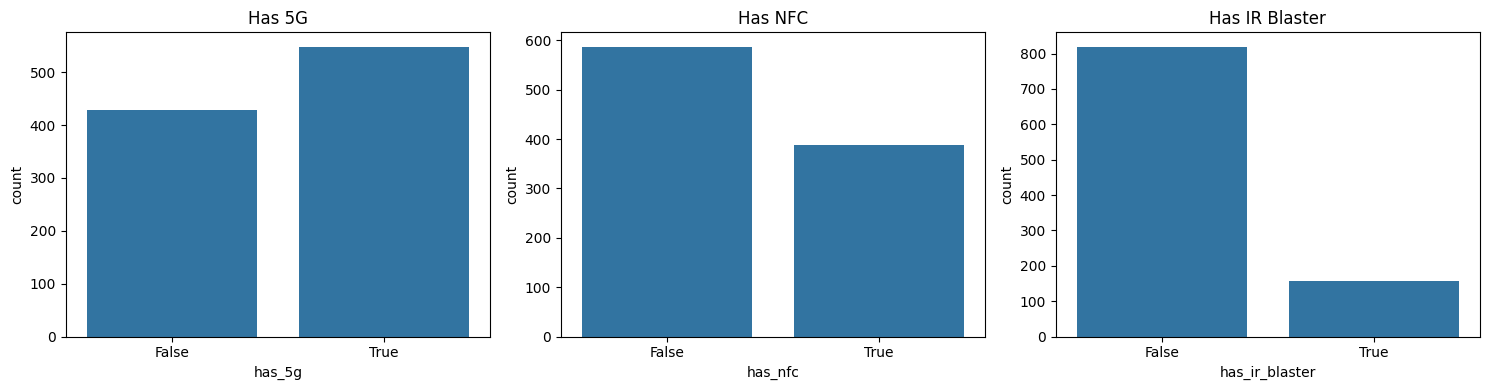

In [20]:
# has_5g has_nfc has_ir_blaster of count plot

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="has_5g", ax=axes[0])
axes[0].set_title("Has 5G")

sns.countplot(data=df, x="has_nfc", ax=axes[1])
axes[1].set_title("Has NFC")

sns.countplot(data=df, x="has_ir_blaster", ax=axes[2])
axes[2].set_title("Has IR Blaster")

plt.tight_layout()
plt.show()

- has_5g has_nfc has_ir_blaster column

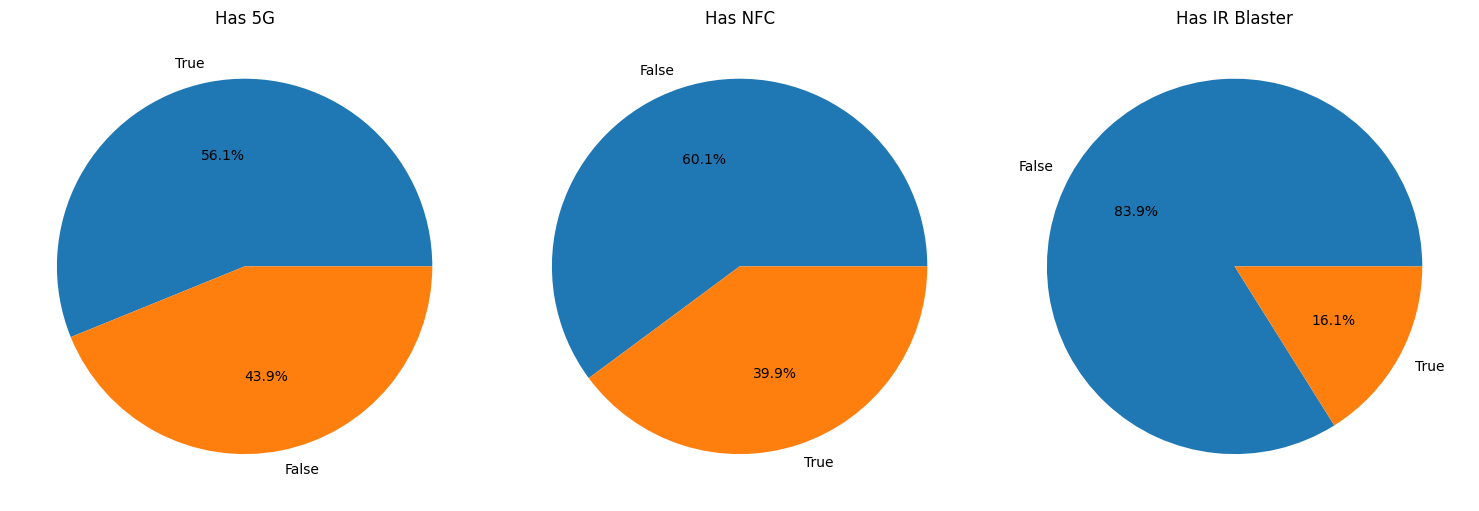

In [21]:
# has_5g has_nfc has_ir_blaster pie chart

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df["has_5g"].value_counts().plot(
    kind="pie", autopct="%0.1f%%", ax=axes[0]
)
axes[0].set_title("Has 5G")
axes[0].set_ylabel("")

df["has_nfc"].value_counts().plot(
    kind="pie", autopct="%0.1f%%", ax=axes[1]
)
axes[1].set_title("Has NFC")
axes[1].set_ylabel("")

df["has_ir_blaster"].value_counts().plot(
    kind="pie", autopct="%0.1f%%", ax=axes[2]
)
axes[2].set_title("Has IR Blaster")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

- processor_brand column

In [22]:
temp_df = df[df['processor_brand'] == 'mediatek']
df.loc[temp_df.index, 'processor_brand'] = 'dimensity'

<Axes: xlabel='processor_brand'>

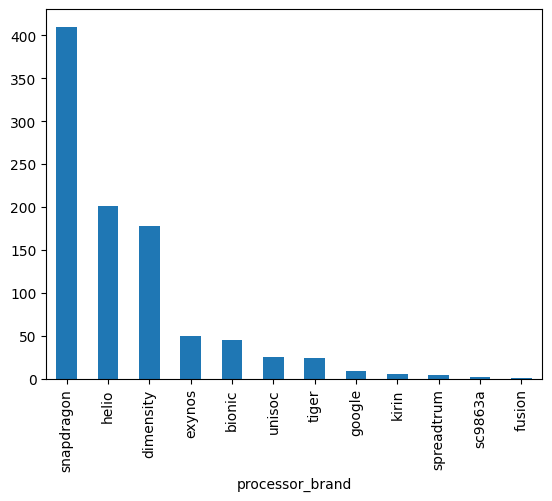

In [23]:
df["processor_brand"].value_counts().plot(kind="bar")

num_cores column

<Axes: ylabel='count'>

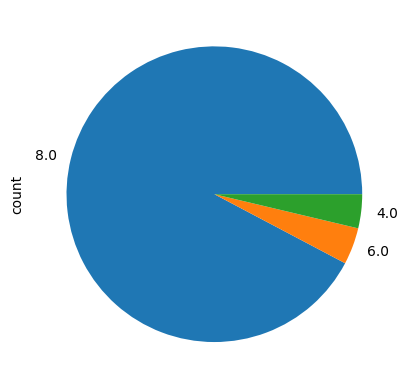

In [24]:
df["num_cores"].value_counts().plot(kind="pie")

In [25]:
df["num_cores"].isnull().sum()

np.int64(6)

processor_speed column

In [26]:
df["processor_speed"].max()

np.float64(3.22)

In [27]:
# Top 10 processor_speed Phones
df.sort_values(by="processor_speed", ascending=False).head(10)

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
6,apple,Apple iPhone 14,65999,81.0,True,True,False,bionic,6.0,3.22,...,6.1,60,1170 x 2532,2,1.0,ios,12.0,12.0,0,NaN
920,apple,Apple iPhone 13 Pro (1TB),147900,84.0,True,True,False,bionic,6.0,3.22,...,6.1,120,1170 x 2532,3,1.0,ios,12.0,12.0,0,NaN
56,apple,Apple iPhone 14 Plus,74999,82.0,True,True,False,bionic,6.0,3.22,...,6.7,60,1284 x 2778,2,1.0,ios,12.0,12.0,0,NaN
76,apple,Apple iPhone 13 Pro,119900,83.0,True,True,False,bionic,6.0,3.22,...,6.1,120,1170 x 2532,3,1.0,ios,12.0,12.0,0,NaN
434,apple,Apple iPhone SE 3 2022,43900,NaN,True,True,False,bionic,6.0,3.22,...,4.7,60,750 x 1334,1,1.0,ios,12.0,7.0,0,NaN
519,apple,Apple iPhone 13 Pro (256GB),129900,83.0,True,True,False,bionic,6.0,3.22,...,6.1,120,1170 x 2532,3,1.0,ios,12.0,12.0,0,NaN
15,apple,Apple iPhone 13,62999,79.0,True,True,False,bionic,6.0,3.22,...,6.1,60,1170 x 2532,2,1.0,ios,12.0,12.0,0,NaN
275,apple,Apple iPhone 13 Mini,64900,79.0,True,True,False,bionic,6.0,3.22,...,5.4,60,1080 x 2340,2,1.0,ios,12.0,12.0,0,NaN
246,apple,Apple iPhone 14 (256GB),75999,82.0,True,True,False,bionic,6.0,3.22,...,6.1,60,1170 x 2532,2,1.0,ios,12.0,12.0,0,NaN
680,apple,Apple iPhone 13 Pro Max (256GB),139900,84.0,True,True,False,bionic,6.0,3.22,...,6.7,120,1284 x 2778,3,1.0,ios,12.0,12.0,0,NaN


In [28]:
df["processor_speed"].isnull().sum()

np.int64(42)

battery_capacity column

In [29]:
df["battery_capacity"].describe()

count      965.000000
mean      4821.681865
std       1007.901153
min       1821.000000
25%       4500.000000
50%       5000.000000
75%       5000.000000
max      22000.000000
Name: battery_capacity, dtype: float64

fast_charging_available

In [30]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
bool_cols = df.select_dtypes(include=["bool"]).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)
print("Boolean Columns:", bool_cols)

Numerical Columns: Index(['price', 'rating', 'num_cores', 'processor_speed', 'battery_capacity',
       'fast_charging_available', 'fast_charging', 'ram_capacity',
       'internal_memory', 'screen_size', 'refresh_rate', 'num_rear_cameras',
       'num_front_cameras', 'primary_camera_rear', 'primary_camera_front',
       'extended_memory_available', 'extended_upto'],
      dtype='object')
Categorical Columns: Index(['model', 'processor_brand', 'resolution'], dtype='object')
Boolean Columns: Index(['has_5g', 'has_nfc', 'has_ir_blaster'], dtype='object')


In [31]:
df[num_cols].describe()

,price,rating,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,num_front_cameras,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
count,976.000000,876.000000,970.000000,934.000000,965.000000,976.000000,767.000000,976.000000,976.000000,976.000000,976.000000,976.000000,972.000000,976.000000,971.000000,976.000000,498.000000
mean,31029.820697,78.262557,7.771134,2.426520,4821.681865,0.854508,46.125163,6.552254,140.237705,6.538596,92.326844,2.814549,1.028807,50.370799,16.588363,0.631148,737.991968
std,29870.079162,7.387218,0.838442,0.463024,1007.901153,0.352777,34.308118,2.734647,105.935485,0.344798,28.978590,0.774884,0.167349,33.045210,10.876863,0.482741,366.363806
min,3499.000000,60.000000,4.000000,1.200000,1821.000000,0.000000,10.000000,1.000000,8.000000,3.540000,60.000000,1.000000,1.000000,2.000000,0.300000,0.000000,32.000000
25%,12999.000000,74.000000,8.000000,2.050000,4500.000000,1.000000,18.000000,4.000000,64.000000,6.500000,60.000000,2.000000,1.000000,24.000000,8.000000,0.000000,512.000000
50%,19990.000000,80.000000,8.000000,2.300000,5000.000000,1.000000,33.000000,6.000000,128.000000,6.580000,90.000000,3.000000,1.000000,50.000000,16.000000,1.000000,1024.000000
75%,34999.000000,84.000000,8.000000,2.840000,5000.000000,1.000000,66.000000,8.000000,128.000000,6.670000,120.000000,3.000000,1.000000,64.000000,16.000000,1.000000,1024.000000
max,199990.000000,89.000000,8.000000,3.220000,22000.000000,1.000000,240.000000,18.000000,1024.000000,8.030000,240.000000,4.000000,2.000000,200.000000,60.000000,1.000000,2048.000000


Numerical Columns – Histogram + KDE

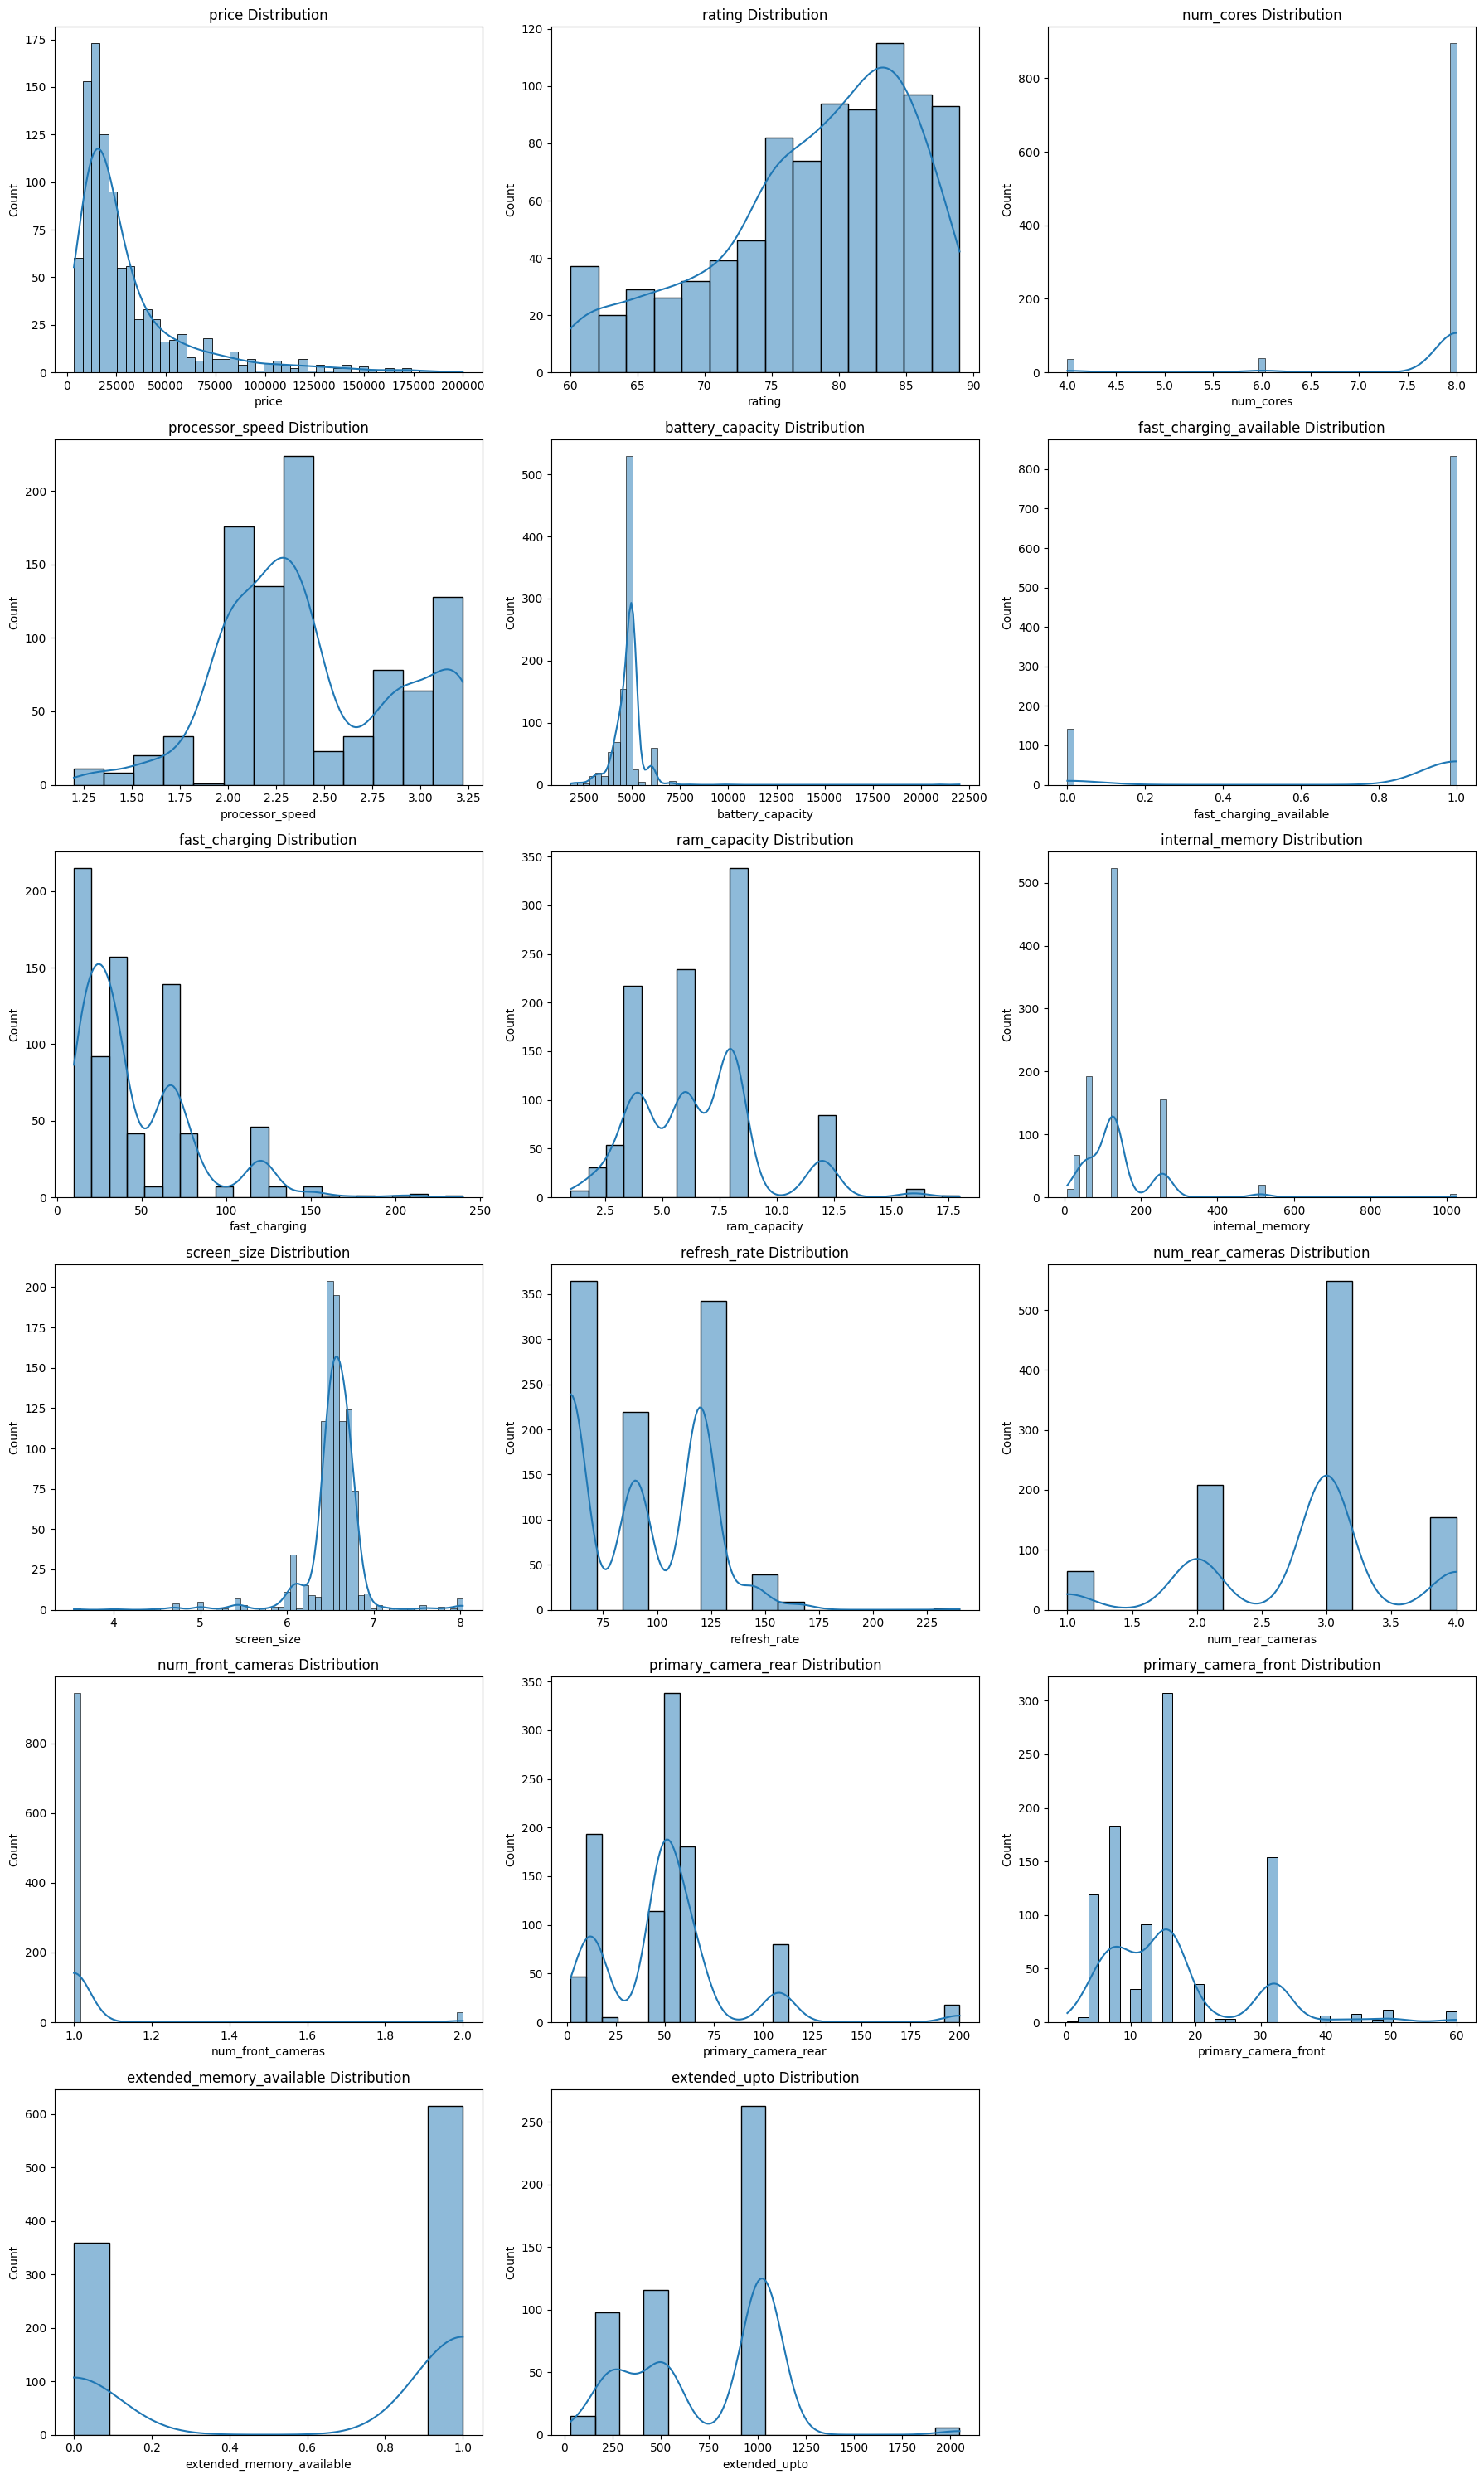

In [32]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

n_cols = 3   # number of plots per row
n_rows = (len(num_cols) // n_cols) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



Numerical Columns – Boxplots Together

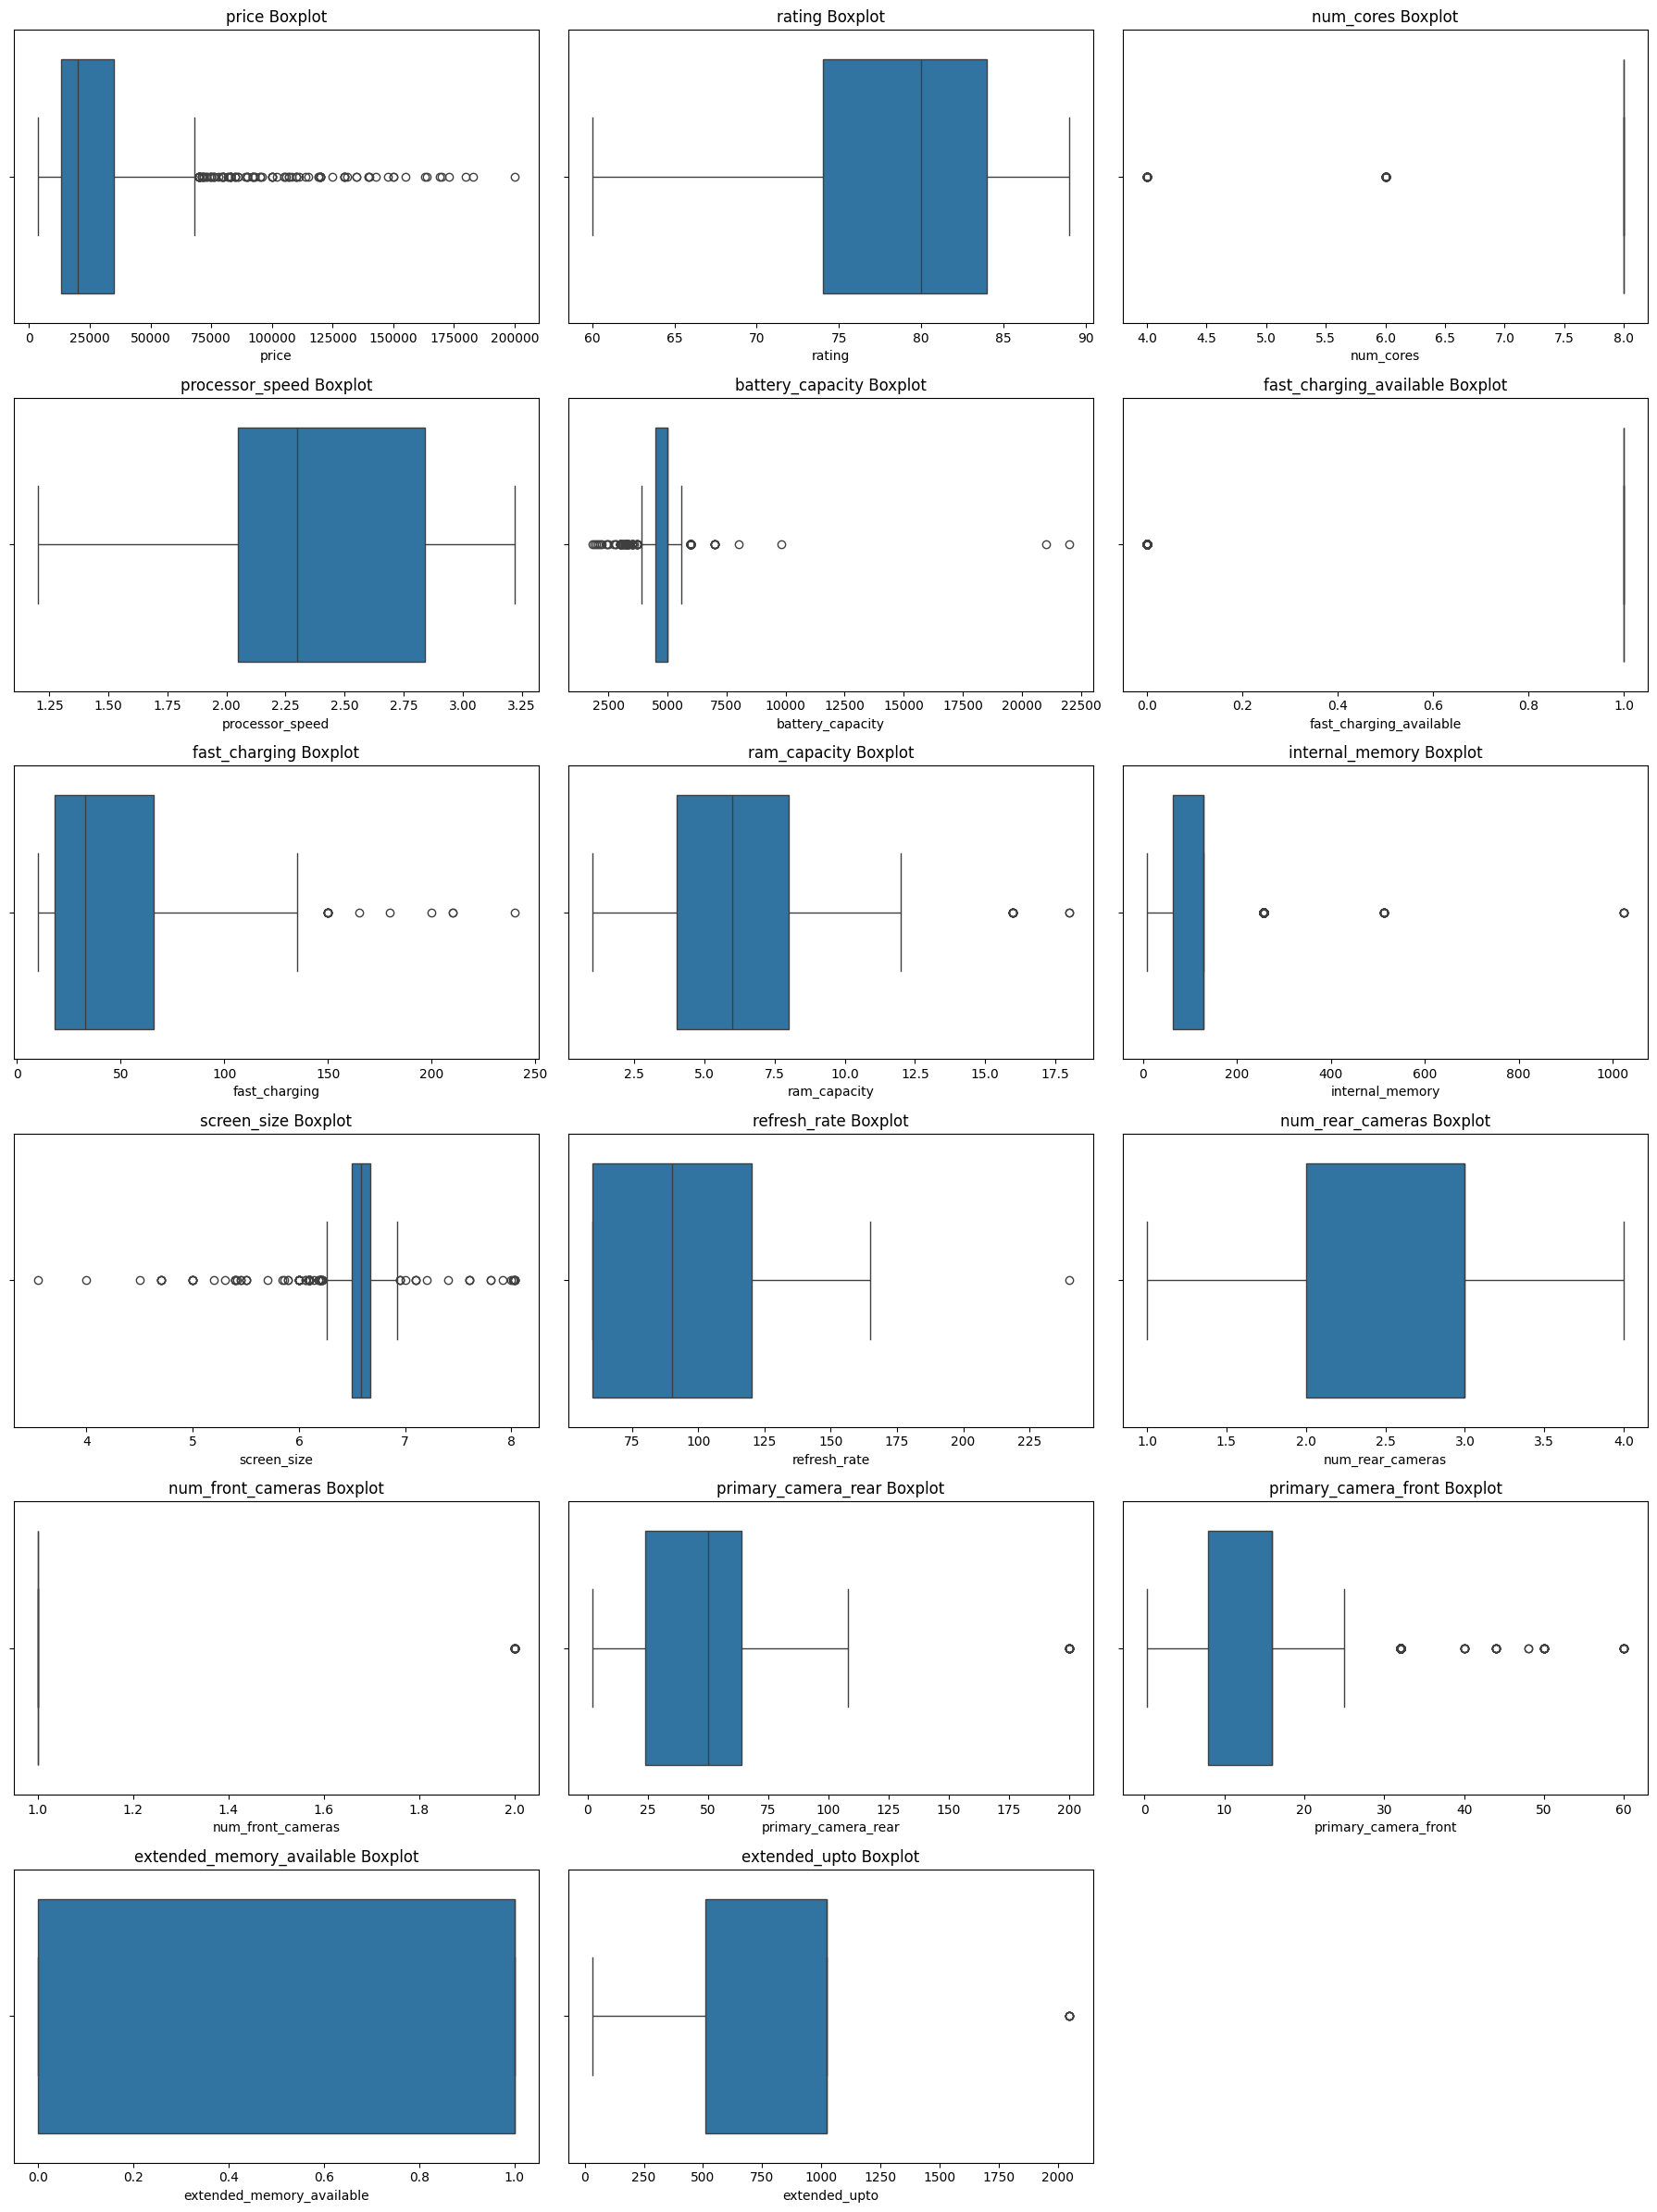

In [33]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Boxplot")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Categorical Column

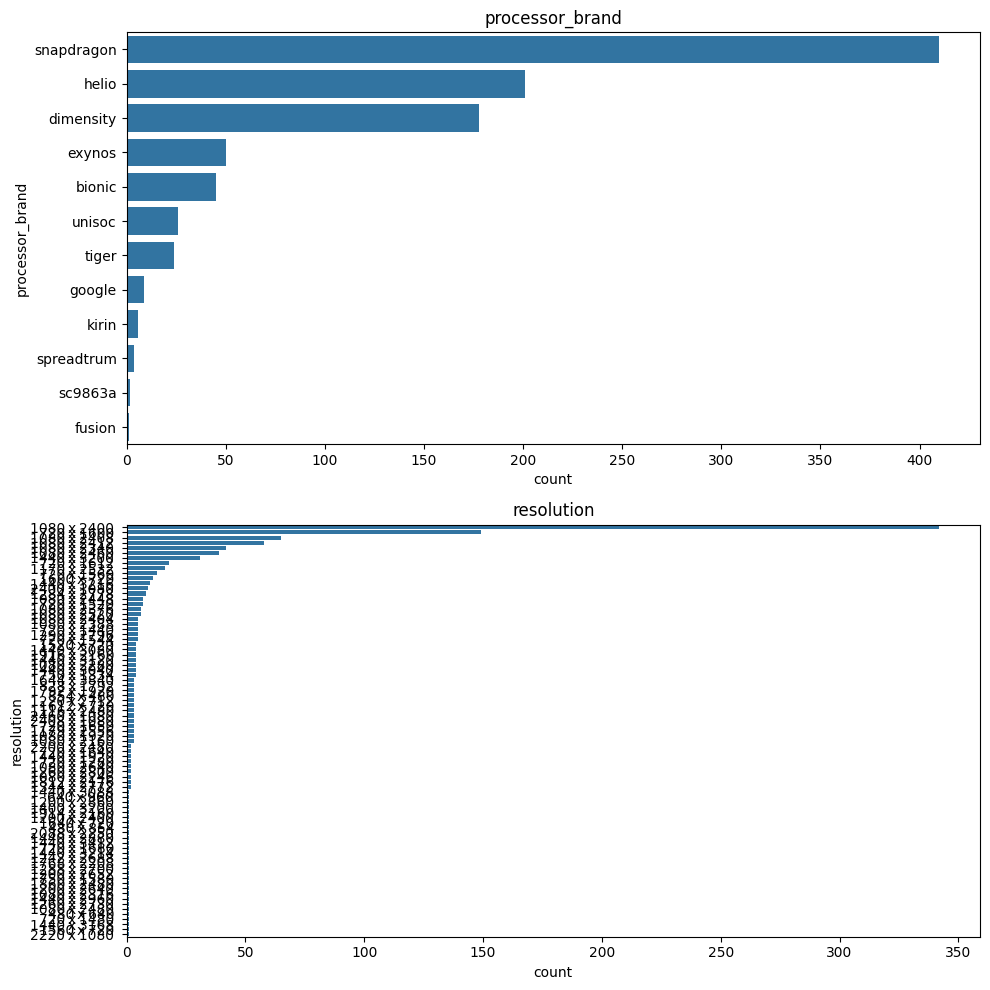

In [34]:
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols = cat_cols.drop("model")

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 5*len(cat_cols)))

for i, col in enumerate(cat_cols):
    sns.countplot(y=df[col], order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [35]:
df[num_cols].skew().sort_values(ascending=False)

battery_capacity             9.350479
num_front_cameras            5.642889
internal_memory              3.911439
price                        2.380118
primary_camera_rear          1.767552
fast_charging                1.645576
primary_camera_front         1.445352
ram_capacity                 0.754163
refresh_rate                 0.295264
processor_speed              0.197175
extended_upto                0.136087
num_rear_cameras            -0.514824
extended_memory_available   -0.544461
rating                      -0.698093
fast_charging_available     -2.013943
screen_size                 -2.067323
num_cores                   -3.748789
dtype: float64

### Bivariate analysis

Since your goal is price prediction, every feature should now be analyzed against price.

1. Numerical Features vs Price

In [36]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
num_cols = num_cols.drop("price")

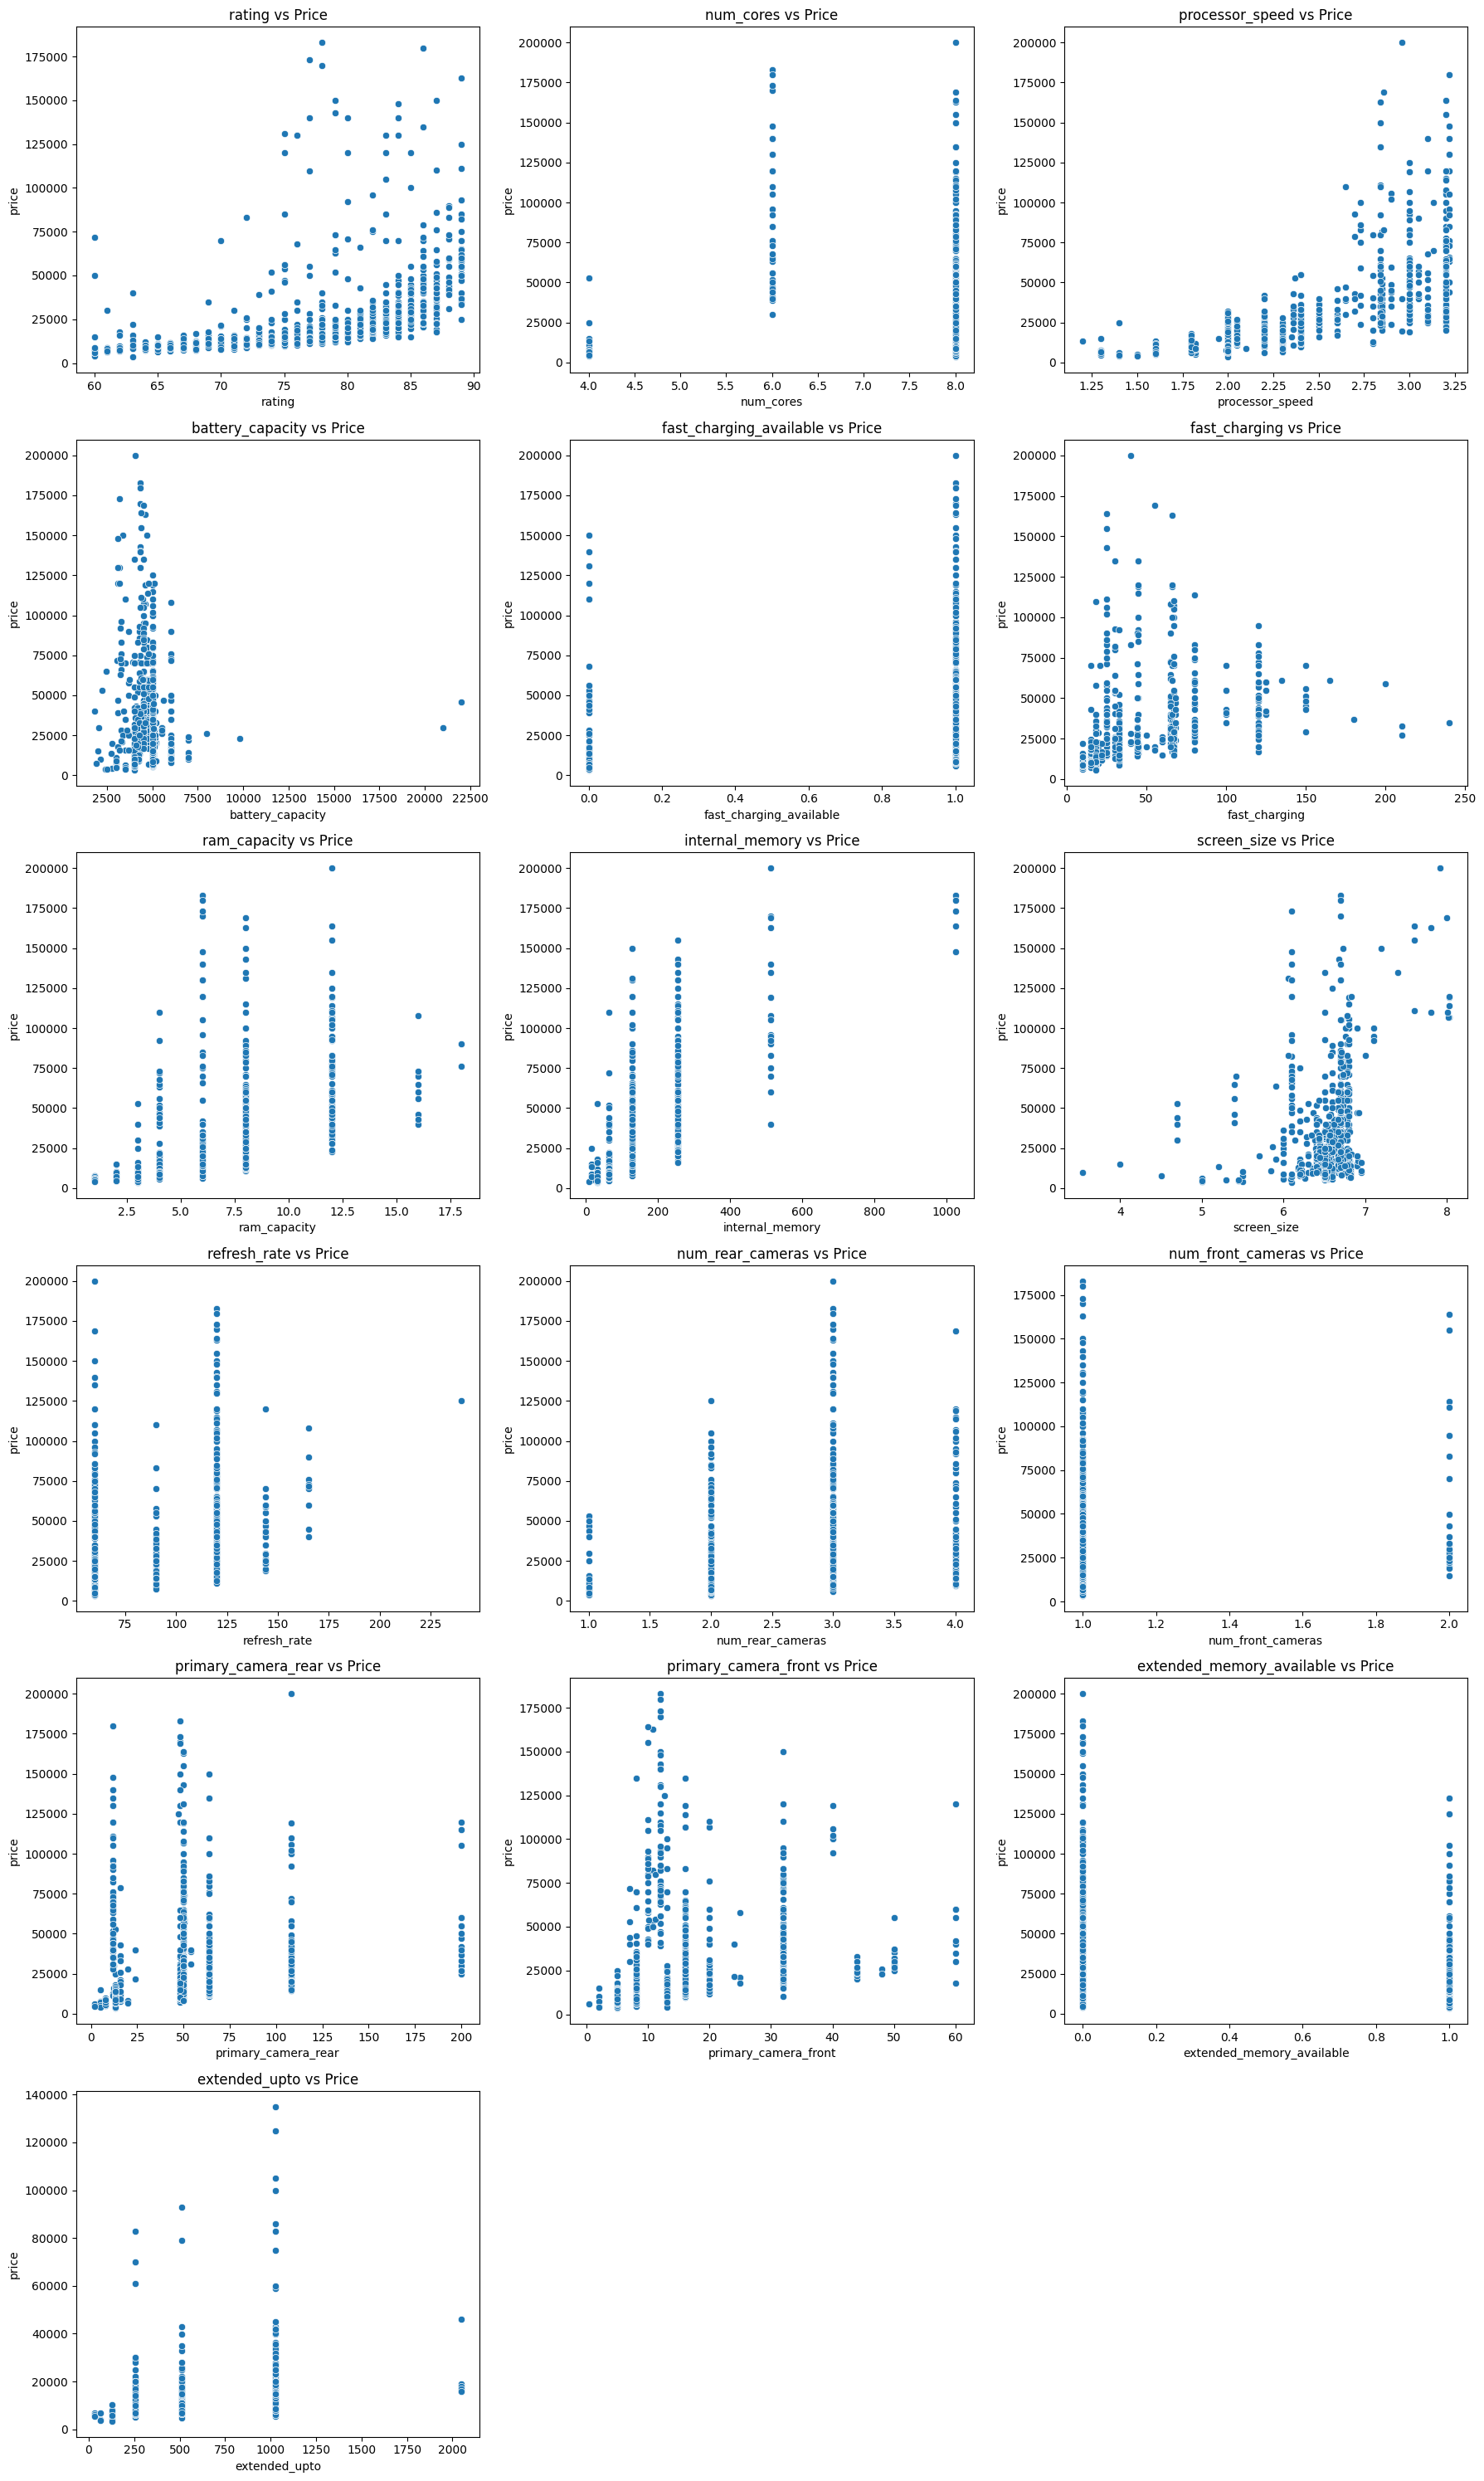

In [37]:
n_cols = 3
n_rows = (len(num_cols) // n_cols) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(x=df[col], y=df["price"], ax=axes[i])
    axes[i].set_title(f"{col} vs Price")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Correlation with Price

In [38]:
corr_with_price = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
corr_with_price

price                        1.000000
internal_memory              0.700274
processor_speed              0.677717
has_nfc                      0.565145
ram_capacity                 0.515265
has_5g                       0.449403
rating                       0.440310
refresh_rate                 0.365485
fast_charging                0.344872
screen_size                  0.268080
primary_camera_front         0.237182
extended_upto                0.203342
num_rear_cameras             0.201566
fast_charging_available      0.194819
primary_camera_rear          0.149347
num_front_cameras            0.127776
has_ir_blaster              -0.035643
num_cores                   -0.078824
battery_capacity            -0.143090
extended_memory_available   -0.558777
Name: price, dtype: float64

Here I observ and decide,
- Strong Positive Correlation (> 0.6)

- Moderate (0.3 – 0.6)

- Weak (< 0.3)

i.e. the strong predictors:

ram_capacity, processor_speed, refresh_rate, primary_camera_rear

Boolean Features vs Price

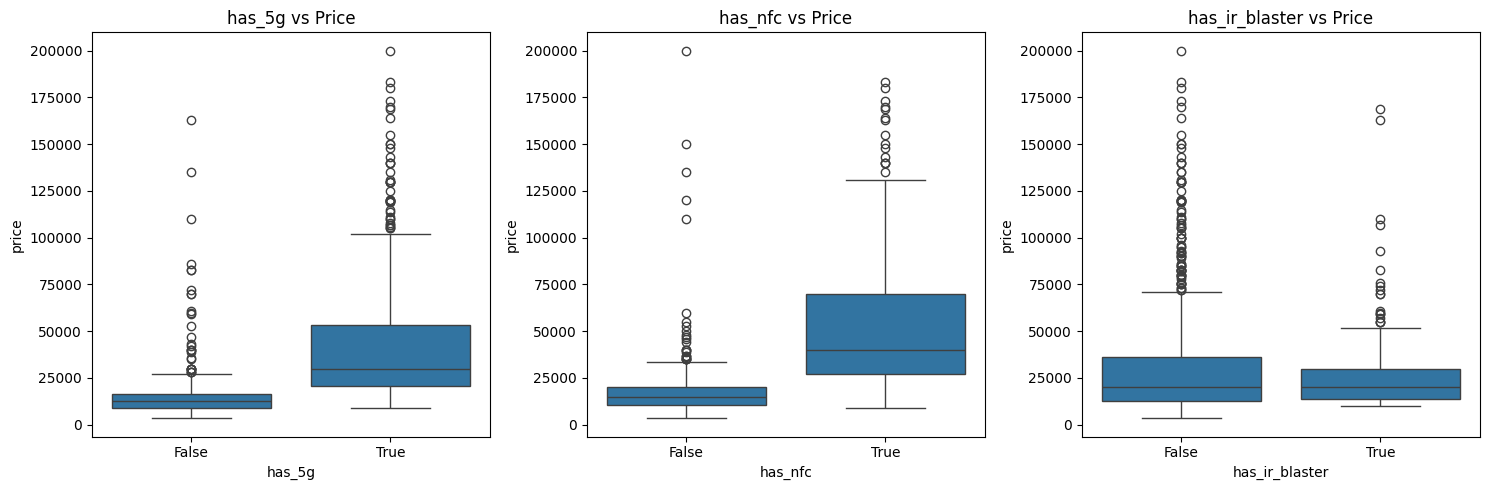

In [39]:
bool_cols = df.select_dtypes(include=["bool"]).columns

fig, axes = plt.subplots(1, len(bool_cols), figsize=(15,5))

for i, col in enumerate(bool_cols):
    sns.boxplot(x=df[col], y=df["price"], ax=axes[i])
    axes[i].set_title(f"{col} vs Price")

plt.tight_layout()
plt.show()

Check Linear Relationship

<Axes: xlabel='ram_capacity', ylabel='price'>

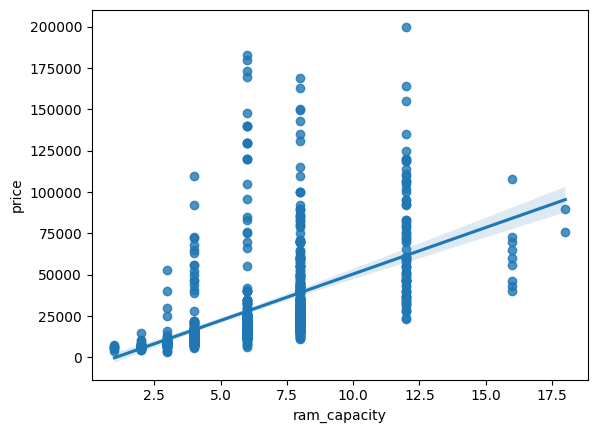

In [40]:
sns.regplot(x="ram_capacity", y="price", data=df)

Relationship Between RAM and Price

- The regression line shows a positive relationship between RAM capacity and price.
- As RAM increases, price also tends to increase.
- The spread of data suggests a moderately strong linear relationship.
- Higher RAM devices are positioned in the premium price segment.

Conclusion:
RAM capacity appears to be an important predictor of smartphone price.

 Bivariate Insights

- RAM capacity shows strong positive correlation with price.
- Processor speed moderately increases price.
- 5G phones have significantly higher average price.
- iOS phones are priced higher than Android devices.
- Refresh rate above 120Hz significantly increases price.

### Multivariate Analysis

Correlation Heatmap

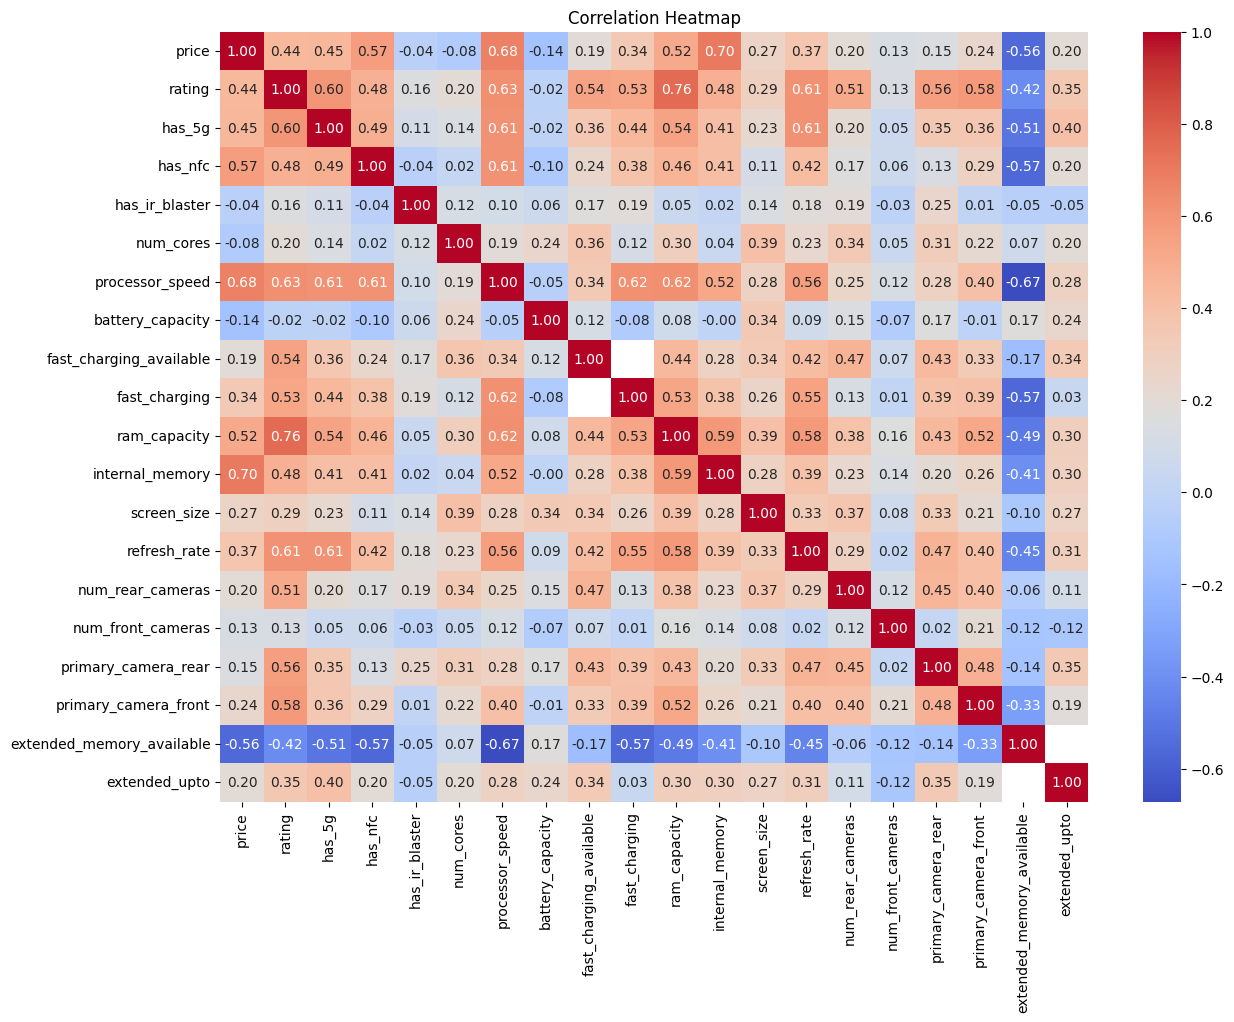

In [41]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

Strong Positive Correlation:
- ram_capacity
- processor_speed
- refresh_rate

Moderate Correlation:
- primary_camera_rear
- internal_memory

Weak Correlation:
- battery_capacity
- number_of_cameras

Conclusion:
RAM capacity is the strongest numerical predictor of smartphone price.

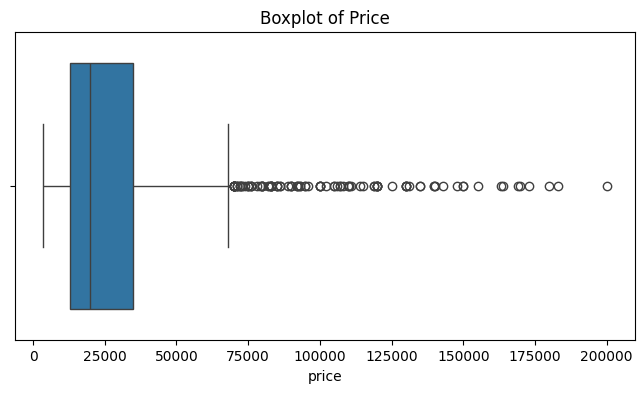

In [42]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.show()

In [43]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
outliers.shape

Lower Bound: -20001.0
Upper Bound: 67999.0


(103, 25)

In [44]:
# Remove the outlires
df_clean = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (976, 25)
After Removing Outliers: (873, 25)


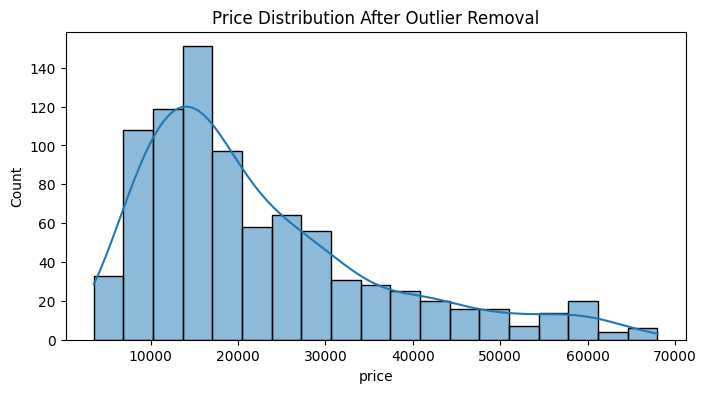

In [45]:
plt.figure(figsize=(8,4))
sns.histplot(df_clean["price"], kde=True)
plt.title("Price Distribution After Outlier Removal")
plt.show()

### Feature Engeneering 

In [46]:
df_clean.isnull().sum()

brand_name                     0
model                          0
price                          0
rating                        57
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand               19
num_cores                      1
processor_speed               25
battery_capacity               8
fast_charging_available        0
fast_charging                176
ram_capacity                   0
internal_memory                0
screen_size                    0
refresh_rate                   0
resolution                     0
num_rear_cameras               0
num_front_cameras              1
os                             3
primary_camera_rear            0
primary_camera_front           2
extended_memory_available      0
extended_upto                386
dtype: int64

In [47]:
df_clean

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,snapdragon,8.0,3.20,...,6.70,120,1440 x 3216,3,1.0,android,50.0,16.0,0,NaN
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,snapdragon,8.0,2.20,...,6.59,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,exynos,8.0,2.40,...,6.60,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,snapdragon,8.0,2.20,...,6.55,120,1080 x 2400,3,1.0,android,50.0,16.0,1,1024.0
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,dimensity,8.0,2.60,...,6.70,120,1080 x 2412,3,1.0,android,108.0,16.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971,motorola,Motorola Moto Edge S30 Pro,34990,83.0,True,False,False,snapdragon,8.0,3.00,...,6.67,120,1080 x 2460,3,1.0,android,64.0,16.0,0,NaN
972,honor,Honor X8 5G,14990,75.0,True,False,False,snapdragon,8.0,2.20,...,6.50,60,720 x 1600,3,1.0,android,48.0,8.0,1,1024.0
973,poco,POCO X4 GT 5G (8GB RAM + 256GB),28990,85.0,True,True,True,dimensity,8.0,2.85,...,6.60,144,1080 x 2460,3,1.0,android,64.0,16.0,0,NaN
974,motorola,Motorola Moto G91 5G,19990,80.0,True,True,False,snapdragon,8.0,2.20,...,6.80,60,1080 x 2400,3,1.0,android,108.0,32.0,1,1024.0


Fill the all null value

In [48]:
df_clean[df_clean["rating"].isnull()]["model"]
df_clean["rating"].fillna(df_clean["rating"].mean(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12676\3711229037.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["rating"].fillna(df_clean["rating"].mean(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_12676\3711229037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["rating"].fillna(df_clean["rating"].mean(), inpla

In [51]:
df_clean[df_clean["processor_brand"].isnull()]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
143,jio,Jio Phone 3,4499,77.922794,False,False,False,NaN,4.0,1.4,...,5.00,60,720 x 1280,1,1.0,android,5.0,2.0,1,128.0
187,ikall,iKall Z19 Pro,8099,60.000000,False,False,False,NaN,4.0,1.6,...,6.50,60,720 x 1600,1,1.0,android,13.0,8.0,1,128.0
200,samsung,Samsung Galaxy A13,14450,75.000000,False,False,False,NaN,8.0,2.0,...,6.60,60,1080 x 2408,4,1.0,android,50.0,8.0,1,1024.0
307,samsung,Samsung Galaxy A13 (4GB RAM + 128GB),14999,75.000000,False,False,False,NaN,8.0,2.0,...,6.60,60,1080 x 2408,4,1.0,android,50.0,8.0,1,1024.0
313,itel,itel S16 Pro,6990,77.922794,False,False,False,NaN,4.0,1.3,...,6.60,60,1600 x 720,3,1.0,android,8.0,8.0,1,32.0
488,samsung,Samsung Galaxy A15,15990,63.000000,False,False,False,NaN,8.0,NaN,...,6.50,60,720 x 1600,3,1.0,android,48.0,8.0,1,1024.0
521,samsung,Samsung Galaxy F14,14990,67.000000,False,True,False,NaN,8.0,NaN,...,6.62,60,2408 x 1080,3,1.0,android,50.0,16.0,1,1024.0
573,samsung,Samsung Galaxy A13 (6GB RAM + 128GB),16499,78.000000,False,False,False,NaN,8.0,2.0,...,6.60,60,1080 x 2408,4,1.0,android,50.0,8.0,1,1024.0
731,ikall,iKall Z19,7999,61.000000,False,False,False,NaN,4.0,1.6,...,6.50,60,720 x 1600,1,1.0,android,20.0,13.0,1,128.0
751,tecno,Tecno Spark Go 2022,6249,61.000000,False,False,False,NaN,8.0,2.2,...,6.51,60,720 x 1600,2,1.0,android,13.0,8.0,1,256.0


In [52]:
df_clean["processor_brand"].value_counts()

processor_brand
snapdragon    358
helio         201
dimensity     174
exynos         41
unisoc         26
tiger          24
bionic         15
google          6
spreadtrum      4
sc9863a         2
kirin           2
fusion          1
Name: count, dtype: int64

In [58]:
# fill the all the value of processer_brand col
df_clean.loc[143, "processor_brand"] = "dimensity"
df_clean.loc[200, "processor_brand"] = "exynos"
df_clean.loc[307, "processor_brand"] = "exynos"
df_clean.loc[313, "processor_brand"] = "unisoc"
df_clean.loc[488, "processor_brand"] = "dimensity"
df_clean.loc[521, "processor_brand"] = "exynos"
df_clean.loc[573, "processor_brand"] = "exynos"
df_clean.loc[751, "processor_brand"] = "helio"
df_clean.loc[767, "processor_brand"] = "spreadtrum"
df_clean.loc[797, "processor_brand"] = "exynos"
df_clean.loc[798, "processor_brand"] = "snapdragon"
df_clean.loc[842, "processor_brand"] = "kirin"
df_clean.loc[907, "processor_brand"] = "exynos"
df_clean.loc[908, "processor_brand"] = "helio"
df_clean.loc[948, "processor_brand"] = "snapdragon"
df_clean.loc[975, "processor_brand"] = "snapdragon"
df_clean.loc[187, "processor_brand"] = "unknown"
df_clean.loc[731, "processor_brand"] = "unknown"
df_clean.loc[961, "processor_brand"] = "unknown"

In [61]:
df_clean[df_clean["processor_speed"].isnull()]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
78,samsung,Samsung Galaxy A34 5G,24999,75.000000,True,True,False,exynos,8.0,NaN,...,6.50,90,1080 x 2400,4,1.0,android,48.0,13.0,1,1024.0
122,google,Google Pixel 6A,29999,71.000000,True,True,False,google,8.0,NaN,...,6.14,60,1080 x 2400,2,1.0,android,12.2,8.0,0,NaN
129,google,Google Pixel 7A,34990,69.000000,True,True,False,google,8.0,NaN,...,6.10,90,1080 x 2400,2,1.0,android,12.2,8.0,0,NaN
206,samsung,Samsung Galaxy A54 5G,34999,76.000000,True,True,False,exynos,8.0,NaN,...,6.40,120,1080 x 2400,3,1.0,android,50.0,32.0,1,1024.0
224,vivo,Vivo Y02,8999,77.922794,False,False,False,helio,8.0,NaN,...,6.51,60,720 x 1600,1,1.0,android,8.0,5.0,1,1024.0
241,samsung,Samsung Galaxy A75 5G,44999,83.000000,True,True,False,snapdragon,8.0,NaN,...,6.70,120,1080 x 2412,4,1.0,android,108.0,32.0,1,1024.0
255,samsung,Samsung Galaxy S22 FE 5G,51999,79.000000,True,True,False,exynos,8.0,NaN,...,6.40,120,1080 x 2400,3,1.0,android,12.0,32.0,0,NaN
380,letv,Letv Y2 Pro,6999,77.922794,False,False,False,unisoc,8.0,NaN,...,6.50,60,720 x 1560,3,1.0,android,13.0,8.0,0,NaN
425,nokia,Nokia X50 5G,34999,76.000000,True,False,False,snapdragon,NaN,NaN,...,6.81,60,1080 x 2400,4,1.0,android,108.0,32.0,1,NaN
488,samsung,Samsung Galaxy A15,15990,63.000000,False,False,False,dimensity,8.0,NaN,...,6.50,60,720 x 1600,3,1.0,android,48.0,8.0,1,1024.0


In [62]:
df_clean.isnull().sum()

brand_name                     0
model                          0
price                          0
rating                         0
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand                0
num_cores                      1
processor_speed               25
battery_capacity               8
fast_charging_available        0
fast_charging                176
ram_capacity                   0
internal_memory                0
screen_size                    0
refresh_rate                   0
resolution                     0
num_rear_cameras               0
num_front_cameras              1
os                             3
primary_camera_rear            0
primary_camera_front           2
extended_memory_available      0
extended_upto                386
dtype: int64

In [74]:
selected_columns = [
    "ram_capacity",
    "internal_memory",
    "processor_brand",
    "processor_speed",
    "refresh_rate",
    "primary_camera_rear",
    "battery_capacity",
    "has_5g",
    "fast_charging_available",
    "fast_charging",
    "screen_size",
    "num_rear_cameras",
    "num_front_cameras",
    "extended_memory_available",
    "rating",
    "num_cores",
    "has_nfc",
    "price"
]

df_model = df_clean[selected_columns]

df_model.head()

,ram_capacity,internal_memory,processor_brand,processor_speed,refresh_rate,primary_camera_rear,battery_capacity,has_5g,fast_charging_available,fast_charging,screen_size,num_rear_cameras,num_front_cameras,extended_memory_available,rating,num_cores,has_nfc,price
0,12.0,256.0,snapdragon,3.2,120,50.0,5000.0,True,1,100.0,6.70,3,1.0,0,89.0,8.0,True,54999
1,6.0,128.0,snapdragon,2.2,120,64.0,5000.0,True,1,33.0,6.59,3,1.0,1,81.0,8.0,False,19989
2,4.0,64.0,exynos,2.4,90,50.0,5000.0,True,1,15.0,6.60,3,1.0,1,75.0,8.0,False,16499
3,6.0,128.0,snapdragon,2.2,120,50.0,5000.0,True,1,NaN,6.55,3,1.0,1,81.0,8.0,False,14999
4,6.0,128.0,dimensity,2.6,120,108.0,5000.0,True,1,67.0,6.70,3,1.0,0,82.0,8.0,False,24999


In [ ]:
df_model["fast_charging"]

np.float64(30.0)

In [77]:
df_model.loc[df_model["fast_charging_available"] == 0, "fast_charging"] = 18

In [83]:
df_model.loc[df_model["fast_charging_available"] == 1, "fast_charging"] = 65

In [86]:
# export to the csv file

df_model.to_csv("Final_cleaned_to_model.csv", index=False)